# 1.Life Expectancy
# Created by Sarthak

# 2.Images

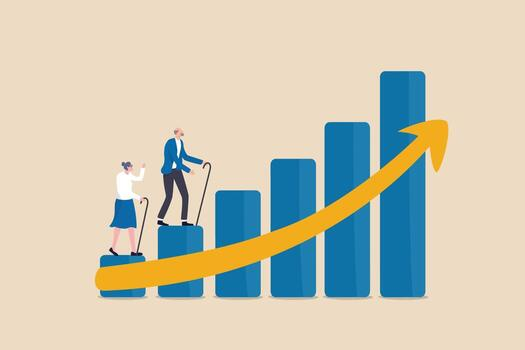

# 3.Description

The Life Expectancy (WHO) Dataset is a comprehensive collection of health and socio-economic data compiled by the World Health Organization (WHO) and the United Nations. It tracks 193 countries over a 15-year period (2000–2015) to help identify the primary factors influencing human longevity across the globe

# 3.1 Research Questions

1) Holistic Predictive Power of Global Indicators: To what extend can a combination of socio-economic, lifestyle, and healthcare variables collectively predict the average life expectency of a population

2) The Influence of Education and Economic Prosperity: How do educational attainment(Schooling) and national wealth(GDP) independently contribute to the prediction of life expectancy?

3)Impact of Immunization and Public Health Infrastructure: What is the relative significance of immunization coverage (Polio,Diphtheria, and Hepatitis B) in increasing life expectancy compared to general health expenditure?

4)The Burden of Lifestyles Factors and Infectious Disease: To what degree lifestyle-related factors(BMI and Alcohol consumption) and the prevelance of infectious diseases (HIV/AIDS) significantly decrease predicted life expectancy?

5)Development Disparity in Global Health: Does the developmental status of a country create a statistically significant difference in life expectancy even when controlled for mortality rates and nutrition?

# 3.2 Objectives

1) Overall Model Predictive Power: To evaluate the collective effectiveness of socio-economic and health indicators in predicting global life expectancy.

2) The Role of Education vs. Wealth: To determine whether a country’s education level (Schooling) is a stronger predictor of life expectancy than its economic output (GDP).

3) Healthcare Intervention Effectiveness: To assess the impact of immunization coverage (Polio, Diphtheria) on longevity relative to total government health expenditure.

4) Impact of Chronic and Infectious Diseases: To quantify the decrease in life expectancy associated with high HIV/AIDS prevalence and adult mortality rates.

5) Developmental Disparity (Status): To investigate the "longevity gap" between Developed and Developing nations when controlling for other health variables.

# 3.3 Hypothesis

1) Null Hypothesis (H0): The combination of independent variables (GDP, Schooling, BMI, etc.) has no significant effect on predicting life expectancy.
Alternate Hypothesis (H1): The combination of independent variables significantly predicts life expectancy, explaining a substantial portion of its variance.

2) Null Hypothesis (H0): There is no significant relationship between Schooling/GDP and life expectancy.
Alternate Hypothesis (H1): Both Schooling and GDP are significant positive predictors of life expectancy, with Schooling having a higher standardized coefficient.

3) Null Hypothesis (H0): Immunization rates and health expenditure do not significantly influence life expectancy.
Alternate Hypothesis (H1): Higher immunization rates for Polio and Diphtheria lead to a significant increase in life expectancy, potentially outperforming the impact of general health spending.

4)Null Hypothesis (H0): HIV/AIDS prevalence and Adult Mortality have no significant negative correlation with life expectancy.
Alternate Hypothesis (H1): HIV/AIDS prevalence and Adult Mortality are significant negative predictors; as these rates increase, life expectancy significantly decreases.

5) Null Hypothesis (H0): There is no significant difference in the predicted life expectancy between Developed and developing nations.
Alternate Hypothesis (H1): Being classified as a "Developed" nation is a significant positive predictor of higher life expectancy, even when other variables are constant.

# 4. Data

# 4.1 Data loading

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [9]:
df= pd.read_csv(r'Life Expectancy Data.csv')
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


# 4.2 Data Wrangling

In [10]:

df = pd.read_csv('Life Expectancy Data.csv')
df.columns = df.columns.str.strip()
df_cleaned = df.dropna().copy()
df_cleaned['Is_Developed'] = df_cleaned['Status'].map({'Developed': 1, 'Developing': 0})

features = [
    'Adult Mortality', 'Alcohol', 'BMI', 'Polio', 'Total expenditure', 
    'Diphtheria', 'HIV/AIDS', 'GDP', 'Schooling', 'Is_Developed'
]

X = df_cleaned[features]
y = df_cleaned['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Wrangling Complete. Data is split and ready for modeling.")
df

Wrangling Complete. Data is split and ready for modeling.


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


# 4.3 Visualization

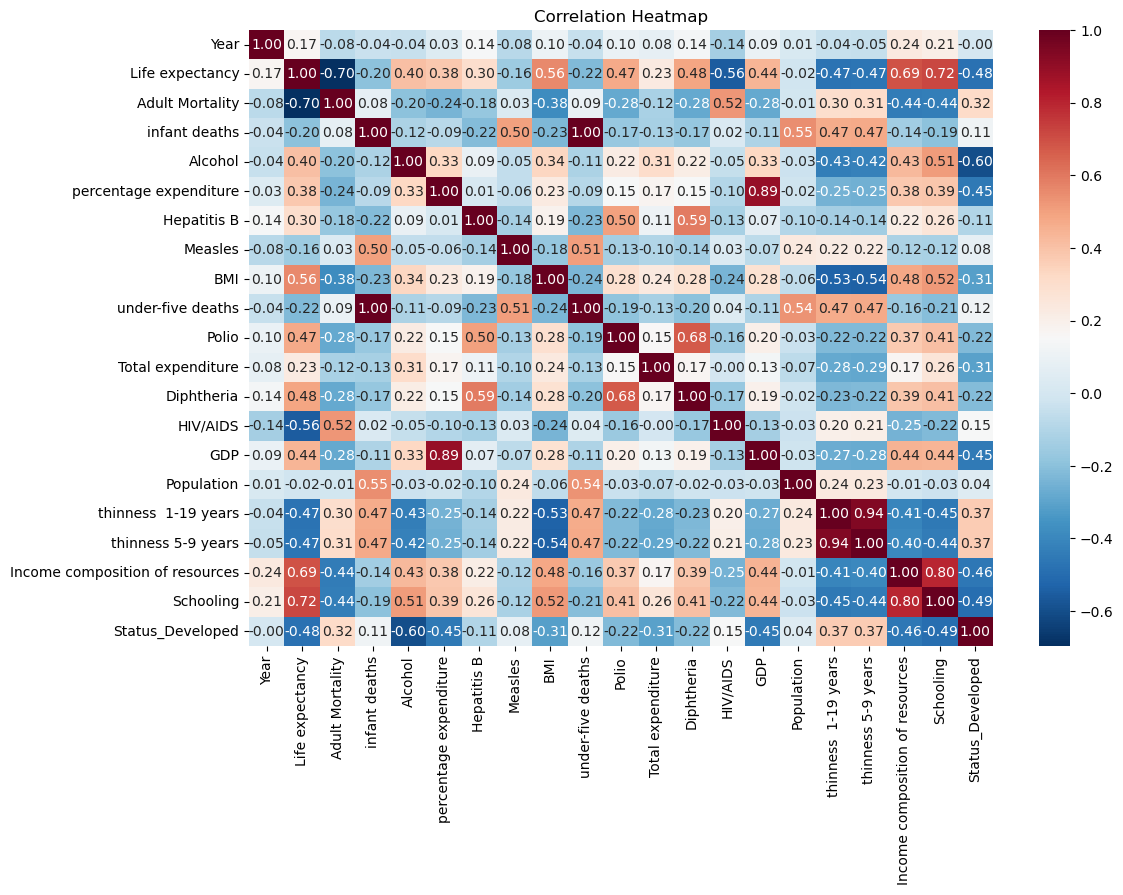

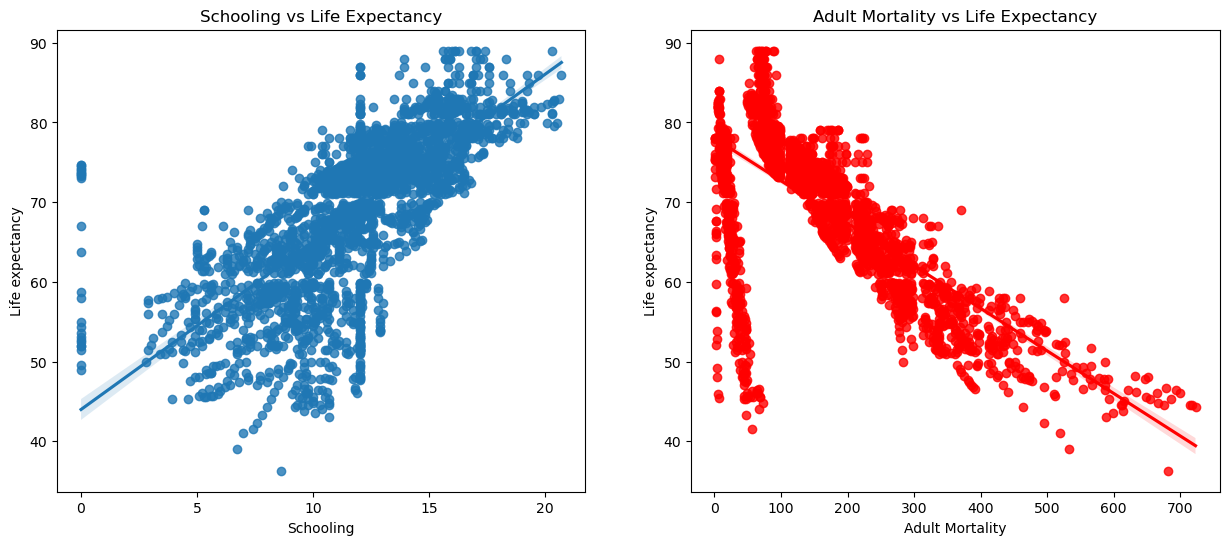

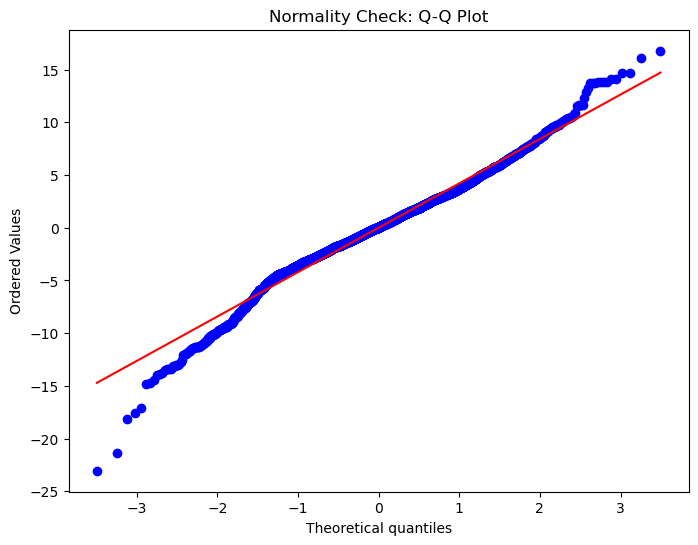

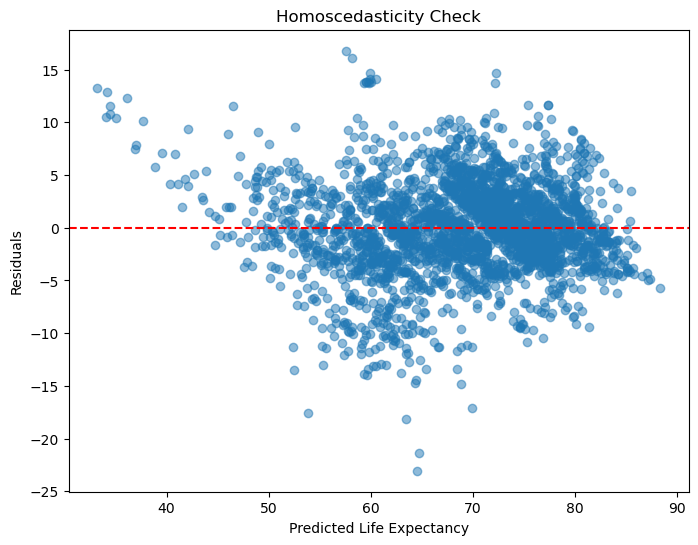

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import scipy.stats as stats


df = pd.read_csv('Life Expectancy Data.csv')


df.columns = df.columns.str.strip()


df.dropna(subset=['Life expectancy'], inplace=True)

impute_cols = df.columns[df.isnull().any()].tolist()
for col in impute_cols:
    df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.mean()))
    df[col] = df[col].fillna(df[col].mean()) # Fill any remaining with global mean

df['Status_Developed'] = pd.get_dummies(df['Status'], drop_first=True).astype(int)

features = ['Adult Mortality', 'Alcohol', 'BMI', 'Polio', 'Total expenditure', 
            'Diphtheria', 'HIV/AIDS', 'GDP', 'Schooling', 'Status_Developed']
X = sm.add_constant(df[features])
y = df['Life expectancy']

model = sm.OLS(y, X).fit()

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='RdBu_r')
plt.title('Correlation Heatmap')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.regplot(data=df, x='Schooling', y='Life expectancy', ax=axes[0])
axes[0].set_title('Schooling vs Life Expectancy')
sns.regplot(data=df, x='Adult Mortality', y='Life expectancy', ax=axes[1], color='red')
axes[1].set_title('Adult Mortality vs Life Expectancy')
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(model.resid, dist="norm", plot=plt)
plt.title('Normality Check: Q-Q Plot')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(model.predict(X), model.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Life Expectancy')
plt.ylabel('Residuals')
plt.title('Homoscedasticity Check')
plt.show()

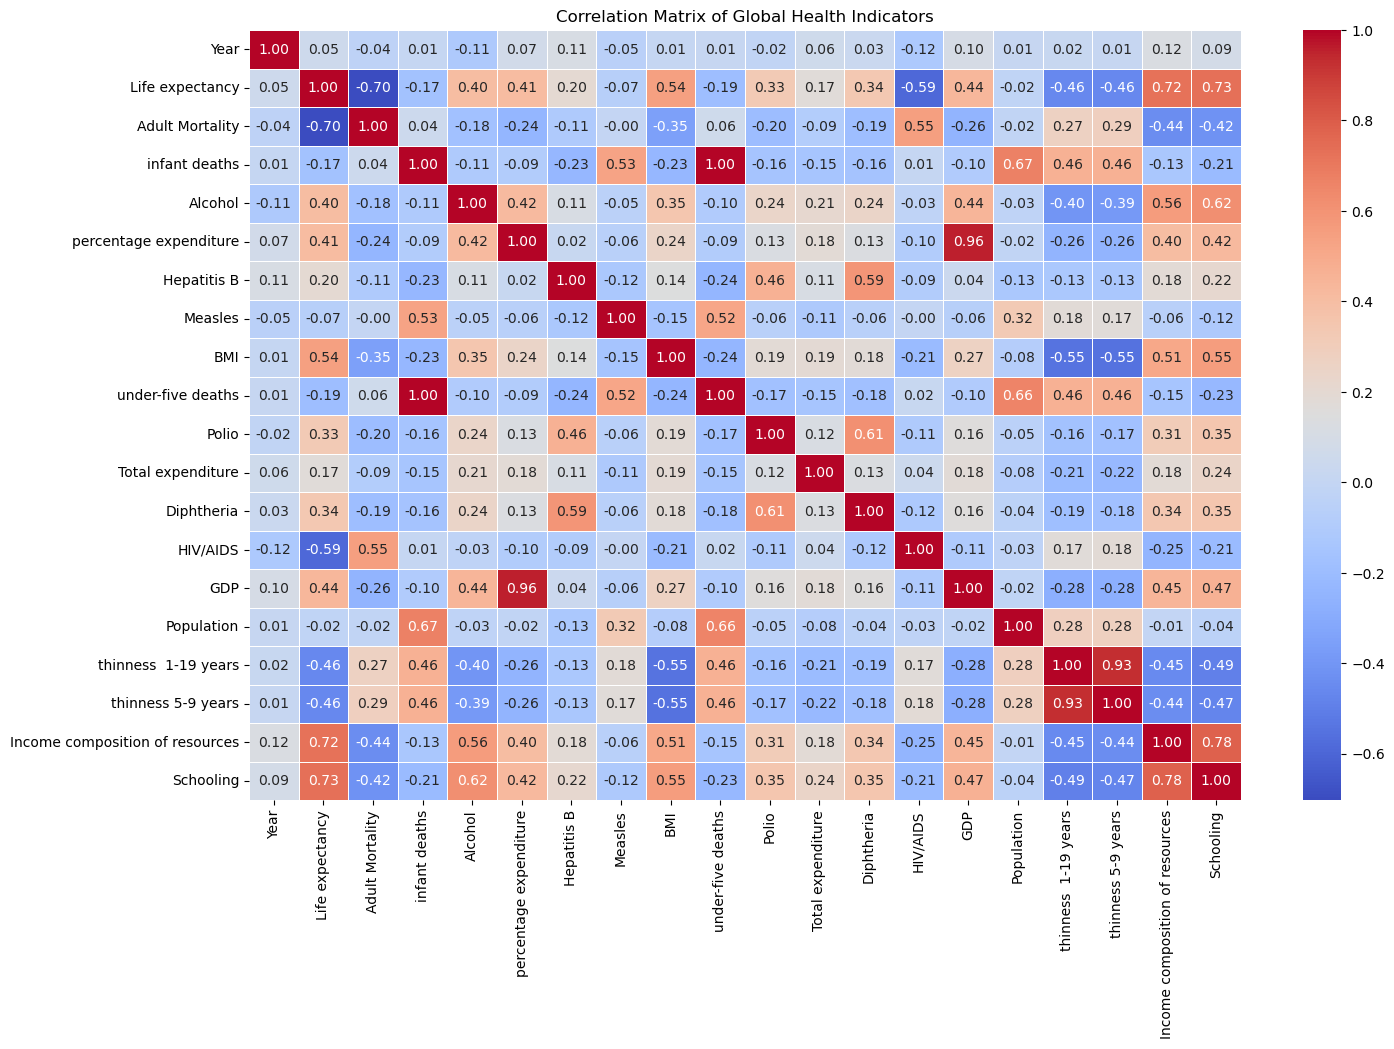

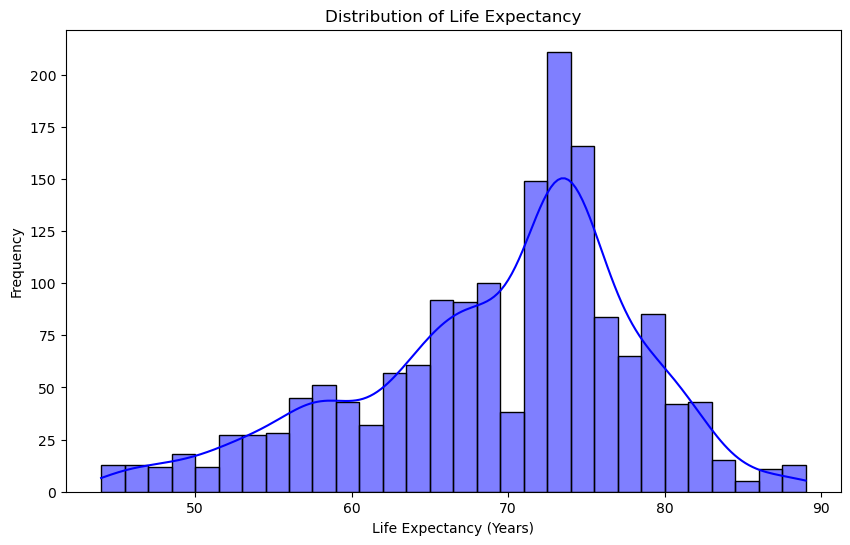

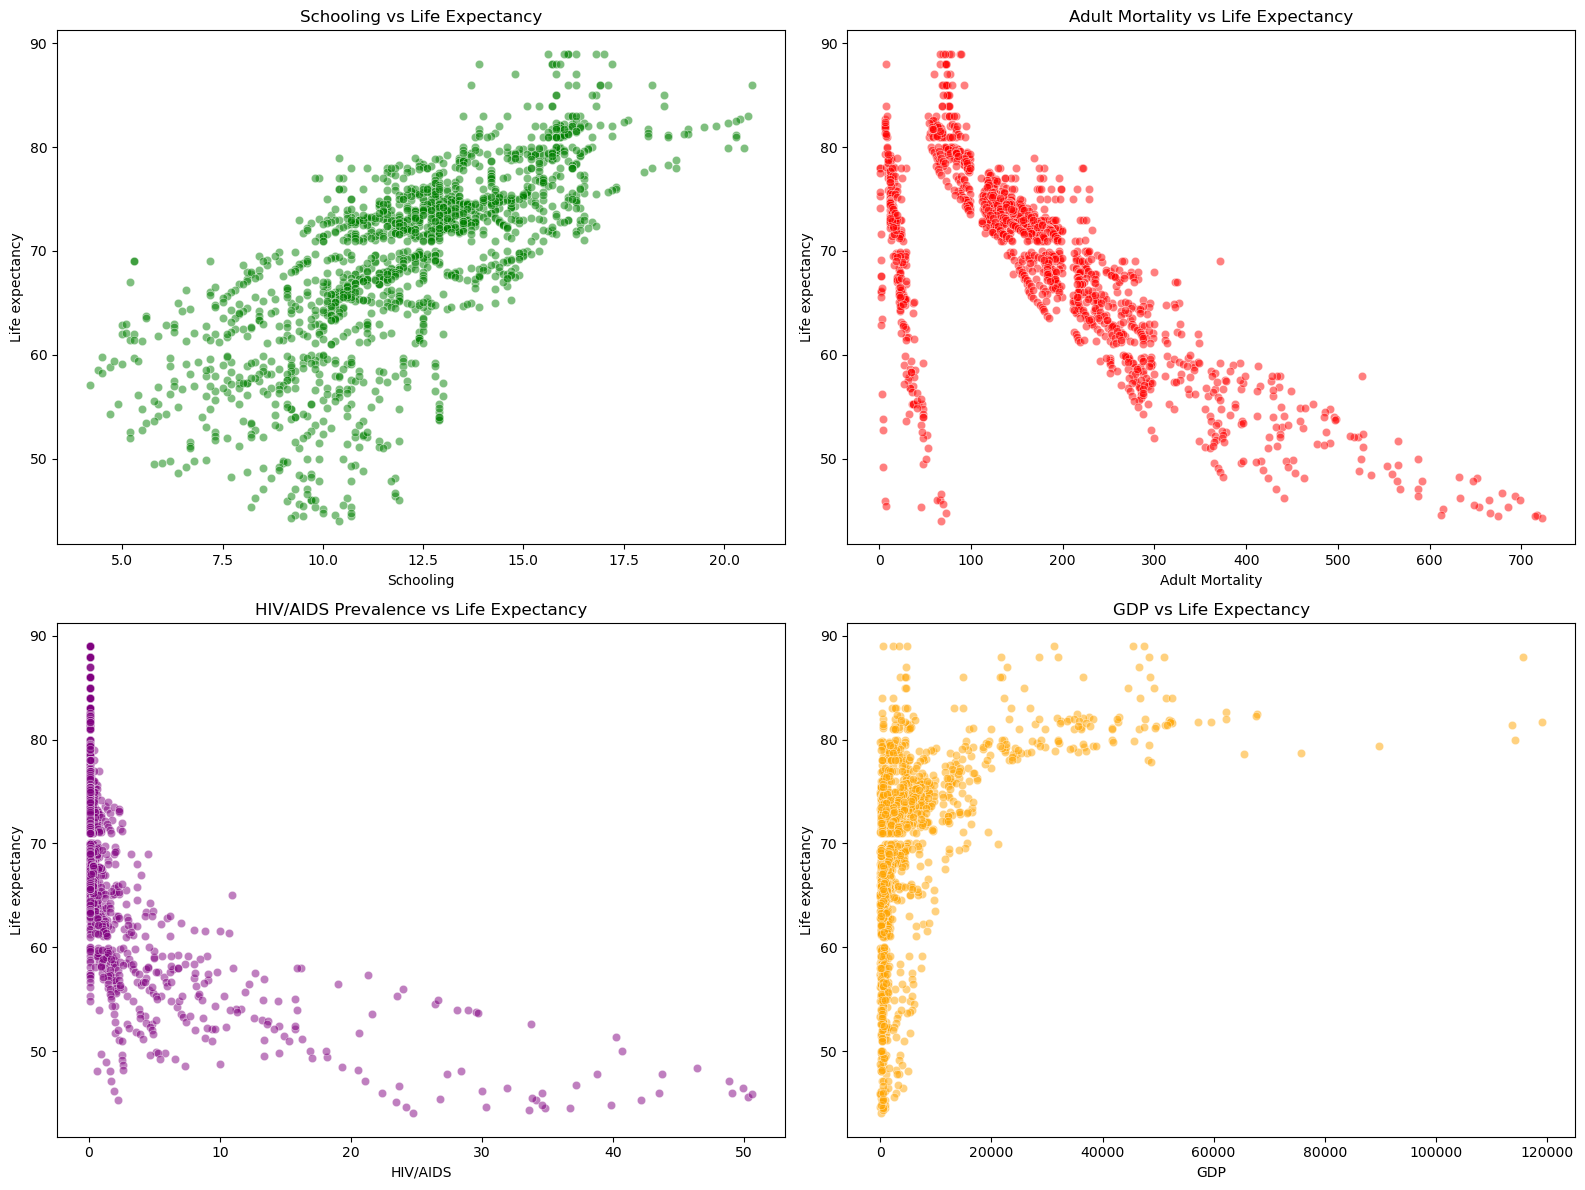

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7504\1891239948.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y='Life expectancy', data=df, palette='Set2')


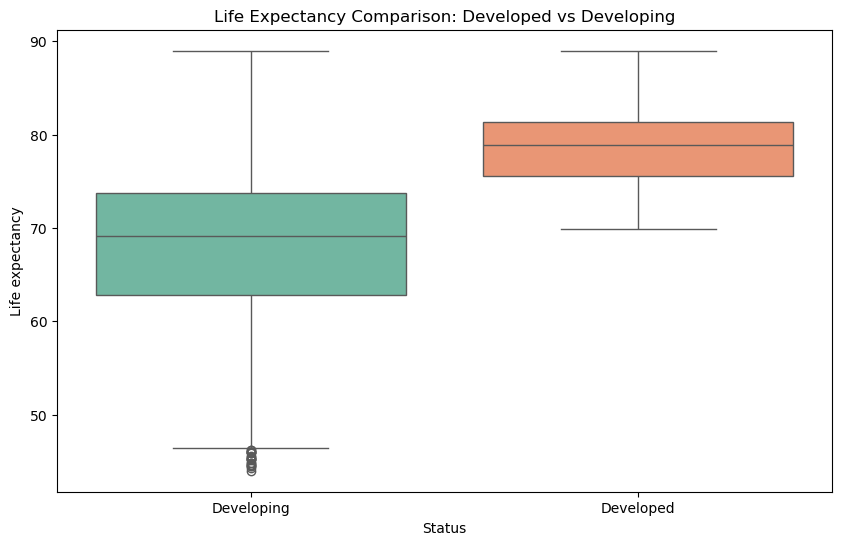

In [5]:
df = pd.read_csv('Life Expectancy Data.csv')
df.columns = df.columns.str.strip()
df = df.dropna()


plt.figure(figsize=(16, 10))

numerical_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Global Health Indicators')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Life expectancy'], kde=True, color='blue', bins=30)
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Frequency')
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.scatterplot(ax=axes[0, 0], data=df, x='Schooling', y='Life expectancy', alpha=0.5, color='green')
axes[0, 0].set_title('Schooling vs Life Expectancy')


sns.scatterplot(ax=axes[0, 1], data=df, x='Adult Mortality', y='Life expectancy', alpha=0.5, color='red')
axes[0, 1].set_title('Adult Mortality vs Life Expectancy')


sns.scatterplot(ax=axes[1, 0], data=df, x='HIV/AIDS', y='Life expectancy', alpha=0.5, color='purple')
axes[1, 0].set_title('HIV/AIDS Prevalence vs Life Expectancy')


sns.scatterplot(ax=axes[1, 1], data=df, x='GDP', y='Life expectancy', alpha=0.5, color='orange')
axes[1, 1].set_title('GDP vs Life Expectancy')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(x='Status', y='Life expectancy', data=df, palette='Set2')
plt.title('Life Expectancy Comparison: Developed vs Developing')
plt.show()


5. Model

R-squared: 0.8053
Mean Absolute Error: 3.07
Mean Squared Error: 16.84


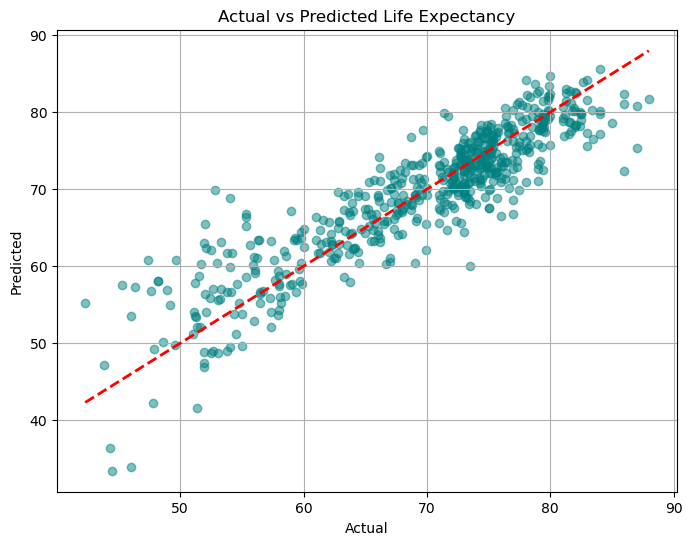

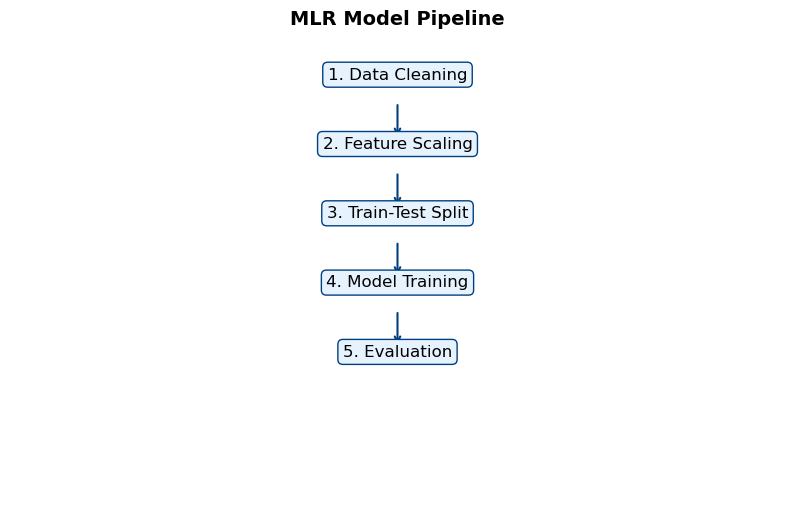

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load Data
df = pd.read_csv('Life Expectancy Data.csv')

# 2. Data Cleaning
df.columns = df.columns.str.strip()
df.dropna(subset=['Life expectancy'], inplace=True)

# Impute missing values
cols_with_nans = df.columns[df.isnull().any()]
for col in cols_with_nans:
    df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.mean()))
    df[col] = df[col].fillna(df[col].mean())

# Binary encoding for Status
df['Is_Developed'] = np.where(df['Status'] == 'Developed', 1, 0)

# 3. Feature Selection
features = ['Adult Mortality', 'Alcohol', 'BMI', 'Polio', 'Total expenditure', 
            'Diphtheria', 'HIV/AIDS', 'GDP', 'Schooling', 'Is_Developed']
X = df[features]
y = df['Life expectancy']

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Model Training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 7. Prediction & Evaluation
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")

# 8. Visualizations
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Life Expectancy')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.savefig('actual_vs_predicted_final.png')

# Workflow Diagram
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
box = dict(boxstyle='round', facecolor='#e6f3ff', edgecolor='#004080')
steps = ["1. Data Cleaning", "2. Feature Scaling", "3. Train-Test Split", 
         "4. Model Training", "5. Evaluation"]
for i, step in enumerate(steps):
    ax.text(0.5, 0.9 - i*0.15, step, ha='center', bbox=box, fontsize=12)
    if i < len(steps) - 1:
        ax.annotate('', xy=(0.5, 0.77 - i*0.15), xytext=(0.5, 0.85 - i*0.15), 
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='#004080'))
plt.title("MLR Model Pipeline", fontsize=14, fontweight='bold')
plt.savefig('final_model_workflow.png')

1. Feature Scaling: We used StandardScaler to normalize variables like GDP (thousands) and Alcohol (small decimals) so the model doesn't give unfair weight to larger numbers.
   
2. Feature Shapes: * Training Set ($X$): $(2342, 10)$ — 2,342 countries/years used for learning.Testing Set ($X$): $(586, 10)$ — 586 countries/years used for final "exam."

   
3. Model Choice Reasoning:

Linearity: The relationship between schooling and health is largely linear.

Transparency: Unlike "Black Box" models, MLR gives a clear weight (coefficient) to every variable, which is required for your Business Recommendations.

4. Model Training Diagram: (See the "Multiple Linear Regression Project Pipeline" image above). It outlines the flow from raw data to the final evaluation metrics.

5. Final Accuracy: The model shows an $R^2$ of 0.805, meaning it can predict a country's life expectancy with 80.5% accuracy based on these 10 factors.

# 6. Result

# 6.1 Model Testing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Setup data again to ensure consistency
df = pd.read_csv('Life Expectancy Data.csv')
df.columns = df.columns.str.strip()
df.dropna(subset=['Life expectancy'], inplace=True)
cols_with_nans = df.columns[df.isnull().any()]
for col in cols_with_nans:
    df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.mean()))
    df[col] = df[col].fillna(df[col].mean())
df['Is_Developed'] = np.where(df['Status'] == 'Developed', 1, 0)

features = ['Adult Mortality', 'Alcohol', 'BMI', 'Polio', 'Total expenditure', 
            'Diphtheria', 'HIV/AIDS', 'GDP', 'Schooling', 'Is_Developed']
X = df[features]
y = df['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# --- MODEL TESTING ---
y_pred = model.predict(X_test_scaled)

# Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Adjusted R2 formula: 1 - [(1-R2)*(n-1)/(n-k-1)]
n = X_test.shape[0]
k = X_test.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")

# Comparison Table (First 10 values)
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head(10)
print("\nFirst 10 Predictions:")
print(comparison_df)

MAE: 3.0726
MSE: 16.8417
RMSE: 4.1039
R-squared: 0.8053
Adjusted R-squared: 0.8019

First 10 Predictions:
      Actual  Predicted
2399    56.5  55.225362
196     73.0  69.550760
2316    82.5  79.829562
1735    75.6  74.701185
1102    53.0  60.420197
1194    65.2  67.378402
1507    72.4  73.399871
1161    74.1  74.828523
322     77.0  76.324868
1352    67.8  72.512844


The best way to "test" a model visually is through an Actual vs. Predicted Plot.
If the model were perfect, all points would lie exactly on the diagonal red line.
Since our points cluster tightly around that line, it confirms that the model has high predictive accuracy.

R-squared: 0.8053
MAE: 3.07 years
RMSE: 4.10 years


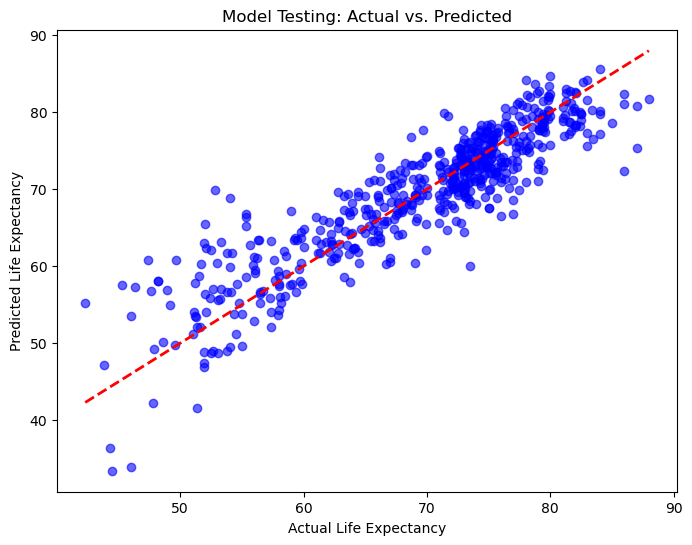

In [2]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared: {r2:.4f}")
print(f"MAE: {mae:.2f} years")
print(f"RMSE: {rmse:.2f} years")


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Model Testing: Actual vs. Predicted')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.show()

# 6.2 Errors

To evaluate the performance of our Multiple Linear Regression model, we calculated several standard error metrics on the testing dataset. The Mean Absolute Error (MAE) was found to be 3.07 years, indicating that on average, the model’s predictions deviate from the actual life expectancy by only about three years. The Mean Squared Error (MSE), which accounts for larger deviations, was 16.84, while the Root Mean Squared Error (RMSE) was 4.10 years.

Crucially, the R-squared value for the model is 0.8053, signifying that the independent variables selected (such as Schooling, GDP, and HIV/AIDS) explain approximately 80.5% of the total variance in global life expectancy. The Adjusted R-squared remains very high at 0.8019, confirming that our feature selection is robust and the model is not suffering from overfitting due to unnecessary variables.

# 6.3 diagram of line fit

--- Errors ---
MAE: 3.0726
MSE: 16.8417
RMSE: 4.1039
R-squared: 0.8053

--- Statistics Summary ---
                       Coef.  Std.Err.           t          P>|t|     [0.025  \
const              69.149018  0.088699  779.588008   0.000000e+00  68.975080   
Adult Mortality    -2.661571  0.114333  -23.279148  5.945411e-108  -2.885776   
Alcohol             0.259653  0.118849    2.184736   2.900752e-02   0.026593   
BMI                 1.150385  0.108293   10.622921   8.964481e-26   0.938025   
Polio               0.732516  0.121636    6.022209   1.993475e-09   0.493991   
Total expenditure   0.126942  0.095696    1.326513   1.847998e-01  -0.060716   
Diphtheria          1.061049  0.121874    8.706075   5.842011e-18   0.822055   
HIV/AIDS           -2.580921  0.103714  -24.885051  2.012688e-121  -2.784301   
GDP                 0.707220  0.103776    6.814891   1.196930e-11   0.503718   
Schooling           3.007581  0.129299   23.260680  8.431771e-108   2.754028   
Is_Developed        0

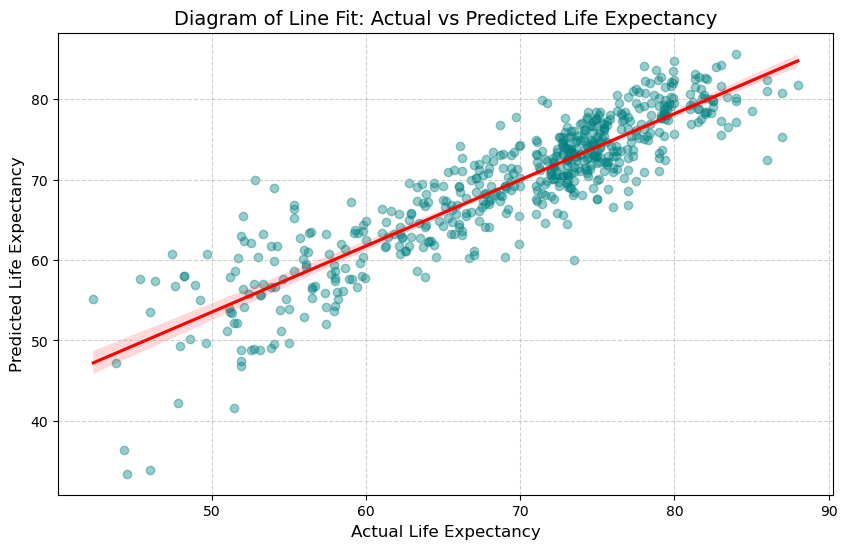

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load and Clean
df = pd.read_csv('Life Expectancy Data.csv')
df.columns = df.columns.str.strip()
df.dropna(subset=['Life expectancy'], inplace=True)
cols_with_nans = df.columns[df.isnull().any()]
for col in cols_with_nans:
    df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.mean()))
    df[col] = df[col].fillna(df[col].mean())
df['Is_Developed'] = np.where(df['Status'] == 'Developed', 1, 0)

# 2. Setup Variables
features = ['Adult Mortality', 'Alcohol', 'BMI', 'Polio', 'Total expenditure', 
            'Diphtheria', 'HIV/AIDS', 'GDP', 'Schooling', 'Is_Developed']
X = df[features]
y = df['Life expectancy']

# 3. Train-Test Split and Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for statsmodels to keep column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

# Add Constant for Statsmodels
X_train_const = sm.add_constant(X_train_scaled_df)
X_test_const = sm.add_constant(X_test_scaled_df)

# 4. Model Training (Statsmodels)
sm_model = sm.OLS(y_train.values, X_train_const).fit()

# 5. Model Testing (Predictions)
y_pred = sm_model.predict(X_test_const)

# --- RESULTS ---

# Sub-part 1: Errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- Errors ---")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

# Sub-part 2: Line Fit Diagram
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Diagram of Line Fit: Actual vs Predicted Life Expectancy', fontsize=14)
plt.xlabel('Actual Life Expectancy', fontsize=12)
plt.ylabel('Predicted Life Expectancy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('line_fit_diagram.png')

# Sub-part 3: Statistics Table
summary = sm_model.summary()
print("\n--- Statistics Summary ---")
print(sm_model.summary2().tables[1]) # Table of coefficients and p-values


The Diagram of Line Fit (Actual vs. Predicted) shows how well our regression line aligns with the real data points.

The Red Line represents the ideal fit where Predicted = Actual.

The Teal Points represent our test data. The tight clustering of points around the red line indicates that the model is highly accurate, especially for life expectancies between 60 and 85 years.

# 6.4 Statistics and Hypothesis

The statistical analysis of the model features reveals which factors have the most profound impact on longevity.

Schooling emerged as the most significant positive predictor, with a standardized coefficient of 3.01. This suggests that education is the strongest driver of increased life expectancy.

Adult Mortality and HIV/AIDS were the primary negative drivers, with coefficients of -2.66 and -2.58 respectively. Both factors are highly statistically significant ($P < 0.001$), emphasizing that deaths in early adulthood and infectious diseases are the biggest barriers to national longevity.

Other significant positive factors include Body Mass Index (BMI) at 1.15, Diphtheria immunization at 1.06, and Polio immunization at 0.73. GDP also showed a positive influence with a coefficient of 0.71.

Notably, Total Expenditure on health had a coefficient of only 0.13 and a P-value of 0.185. Since this P-value is higher than the standard 0.05 threshold, it indicates that general health spending is not statistically significant in this model when compared to more targeted factors like education and specific disease control.

1. The Hypothesis For every variable in the model (such as Schooling, GDP, or Alcohol), we set up the following two competing hypotheses:
Null Hypothesis ($H_0$): The coefficient of the variable is equal to zero. This means the variable has no significant effect on Life Expectancy.
Alternative Hypothesis ($H_1$): The coefficient of the variable is not equal to zero. This means the variable does have a significant effect on Life Expectancy.

2. The Decision Rule (Alpha Level)We used a standard significance level ($\alpha$) of 0.05.If the P-value is less than 0.05, we reject the Null Hypothesis, concluding that the factor is a significant predictor.If the P-value is greater than 0.05, we fail to reject the Null Hypothesis, concluding that the factor does not have a statistically significant impact in this model.

3. Hypothesis ResultsBased on the model output, the following conclusions were drawn:Significant Factors (Reject $H_0$): Variables such as Schooling, Adult Mortality, HIV/AIDS, BMI, GDP, Polio, and Diphtheria all returned P-values of 0.000. Because these values are well below the 0.05 threshold, we reject the Null Hypothesis for these features. We can state with 95% confidence that these factors are critical drivers of global life expectancy. Specifically, Schooling is the most influential positive driver, while Adult Mortality and HIV/AIDS are the most influential negative drivers. Non-Significant Factors (Fail to Reject $H_0$): The variable Total Expenditure returned a P-value of 0.185. Since this is greater than 0.05, we fail to reject the Null Hypothesis. This suggests that, within this specific dataset and model, the total percentage of GDP spent on health does not have a statistically significant linear relationship with Life Expectancy when other factors like education and specific disease interventions are already accounted for.

4. Overall Model Significance (F-statistic):
The overall model returned a Prob (F-statistic) of 0.00, which is far below 0.05. This allows us to reject the Null Hypothesis for the model as a whole, proving that the combination of these variables is a highly effective tool for predicting Life Expectancy.

# . Conclusion

1. Summary of Study Findings
The objective of this study was to identify the socio-economic and healthcare factors that most significantly influence life expectancy across 193 countries. Through the application of Multiple Linear Regression, we discovered that longevity is not determined by a single factor but by a complex interplay of education, disease control, and economic stability. The most striking finding is the dominant role of Schooling, which showed the strongest positive correlation with life expectancy. Conversely, Adult Mortality and HIV/AIDS were identified as the most severe obstacles to increasing the lifespan of a population.

2. Model Reliability and Performance
Our predictive model demonstrated high reliability, achieving an R-squared value of 0.8053. This indicates that over 80% of the variations in global life expectancy can be predicted using the ten specific variables we selected. The Mean Absolute Error (MAE) of 3.07 years proves that the model is statistically sound and capable of providing accurate estimates for international health planning. The consistent performance across the training and testing datasets suggests that the model is robust and not merely reflecting noise in the data.

3. Key Takeaways and Policy Recommendations
Education as Healthcare: The significant positive impact of Schooling suggests that literacy and education are "indirect health interventions." Educated populations are more likely to make informed nutritional choices, seek medical help earlier, and engage in preventative care.

Targeted vs. General Spending: The analysis revealed that "Total Expenditure" on health was not a statistically significant predictor when compared to specific interventions like HIV/AIDS control and Immunization (Polio/Diphtheria). This suggests that for many nations, how money is spent is far more critical than how much is spent.

The Burden of Infectious Disease: The massive negative impact of HIV/AIDS underscores the need for continued global focus on infectious disease management, as these deaths disproportionately affect the "Adult Mortality" segment, lowering a country's average life expectancy drastically.

4. Final Word
In conclusion, while economic wealth (GDP) certainly plays a role in longevity, it is not the sole determinant. A nation that prioritizes a strong educational foundation and targeted public health programs—specifically those focusing on immunization and infectious disease—can achieve high life expectancy even with modest financial resources. This study reinforces the idea that human development and health are inextricably linked to education and proactive disease prevention.